In [1]:
#import Library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing import image

#DATA UNDERSTANDING

##Ekstraksi Dataset

In [2]:
import os
import zipfile

zip_path = "dauntomat.zip"
extract_path = "/content/data"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset berhasil diekstrak!")

Dataset berhasil diekstrak!


##Menentukan Path Dataset

In [3]:
dataset_path = "/content/data/dauntomat"

##Menampilkan nama kelas


In [4]:
classes = sorted([
    folder for folder in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, folder))
])

print("Jumlah kelas :", len(classes))
print("\nNama kelas:")

for cls in classes:
    print("-", cls)

Jumlah kelas : 5

Nama kelas:
- Tomato__early_blight
- Tomato__healthy
- Tomato__late_blight
- Tomato__leaf_mold
- Tomato__septoria_leaf_spot


##Menghitung jumlah gambar tiap kelas

In [5]:
dataset_info = []

for cls in classes:

    folder = os.path.join(dataset_path, cls)

    jumlah = len([
        file for file in os.listdir(folder)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    dataset_info.append([cls, jumlah])

df = pd.DataFrame(
    dataset_info,
    columns=["Kelas", "Jumlah Gambar"]
)

df

,Kelas,Jumlah Gambar
0,Tomato__early_blight,1009
1,Tomato__healthy,1598
2,Tomato__late_blight,1919
3,Tomato__leaf_mold,957
4,Tomato__septoria_leaf_spot,1782


##Visualisasi Distribusi Dataset

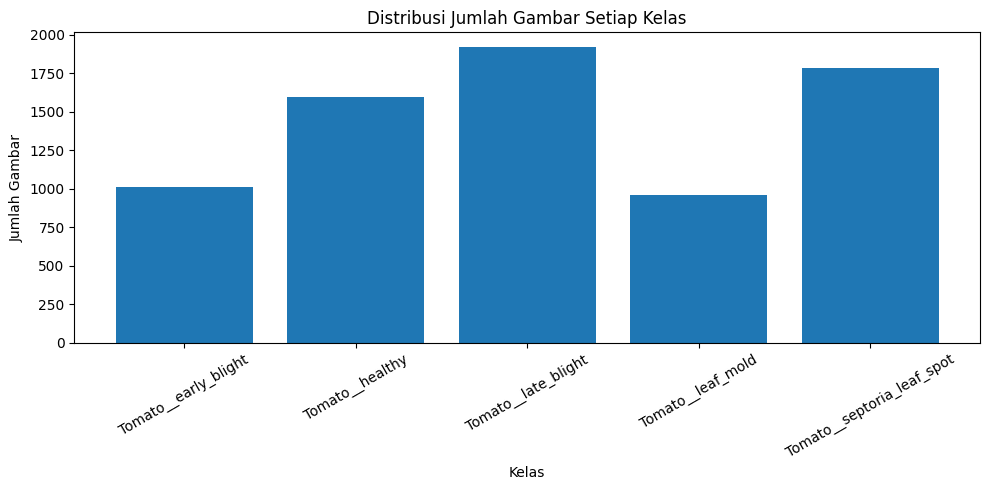

In [6]:
plt.figure(figsize=(10,5))

plt.bar(df["Kelas"], df["Jumlah Gambar"])

plt.title("Distribusi Jumlah Gambar Setiap Kelas")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Gambar")

plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

##Menampilkan Contoh Gambar Setiap Kelas

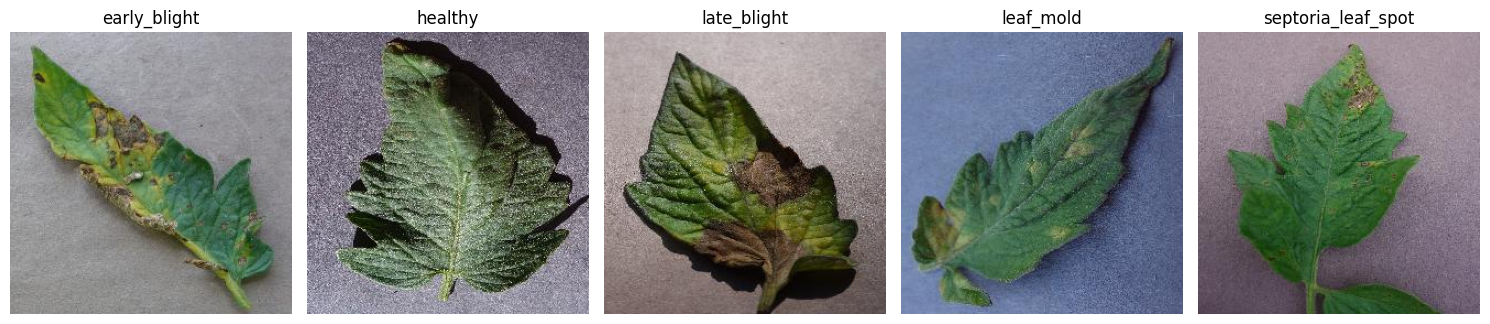

In [7]:
from PIL import Image

plt.figure(figsize=(15,4))

for i, cls in enumerate(classes):

    folder = os.path.join(dataset_path, cls)

    image_name = os.listdir(folder)[0]

    img = Image.open(os.path.join(folder, image_name))

    plt.subplot(1, len(classes), i+1)
    plt.imshow(img)
    plt.title(cls.replace("Tomato__", ""))
    plt.axis("off")

plt.tight_layout()
plt.show()

#DATA PREPARATION

##Membuat DataFrame (filepath dan label)

In [8]:
data = []

for cls in classes:
    folder = os.path.join(dataset_path, cls)
    for file in os.listdir(folder):
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            data.append([
                os.path.join(folder, file),
                cls
            ])

df = pd.DataFrame(
    data,
    columns=["filepath", "label"]
)

df.head()

,filepath,label
0,/content/data/dauntomat/Tomato__early_blight/d...,Tomato__early_blight
1,/content/data/dauntomat/Tomato__early_blight/2...,Tomato__early_blight
2,/content/data/dauntomat/Tomato__early_blight/c...,Tomato__early_blight
3,/content/data/dauntomat/Tomato__early_blight/1...,Tomato__early_blight
4,/content/data/dauntomat/Tomato__early_blight/3...,Tomato__early_blight


##Mengecek Distribusi Label

In [9]:
df["label"].value_counts()

,count
label,
Tomato__late_blight,1919
Tomato__septoria_leaf_spot,1782
Tomato__healthy,1598
Tomato__early_blight,1009
Tomato__leaf_mold,957


##Membagi Dataset (Train, Validation, Test)

###Train 80% dan Test 20%

In [10]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

###Train menjadi Train dan Validation

In [11]:
train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df["label"]
)

##Mengecek Jumlah Data

In [12]:
print("Train :", len(train_df))
print("Validation :", len(val_df))
print("Test :", len(test_df))

Train : 4649
Validation : 1163
Test : 1453


##Membuat ImageDataGenerator

In [13]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

val_test_datagen = ImageDataGenerator(
    rescale=1./255
)

##Membuat Generator

In [14]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 4649 validated image filenames belonging to 5 classes.
Found 1163 validated image filenames belonging to 5 classes.
Found 1453 validated image filenames belonging to 5 classes.


##Mengecek Label Otomatis

In [15]:
print(train_generator.class_indices)

{'Tomato__early_blight': 0, 'Tomato__healthy': 1, 'Tomato__late_blight': 2, 'Tomato__leaf_mold': 3, 'Tomato__septoria_leaf_spot': 4}


#MODELING

In [16]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [17]:
model = Sequential([
    base_model,

    GlobalAveragePooling2D(),

    Dropout(0.3),

    Dense(5, activation="softmax")
])

In [18]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [20]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 101s 571ms/step - accuracy: 0.6561 - loss: 0.9109 - val_accuracy: 0.8117 - val_loss: 0.5614
Epoch 2/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 58s 393ms/step - accuracy: 0.8058 - loss: 0.5467 - val_accuracy: 0.8573 - val_loss: 0.4301
Epoch 3/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 56s 386ms/step - accuracy: 0.8385 - loss: 0.4561 - val_accuracy: 0.8616 - val_loss: 0.3989
Epoch 4/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 57s 390ms/step - accuracy: 0.8466 - loss: 0.4235 - val_accuracy: 0.8762 - val_loss: 0.3597
Epoch 5/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 56s 385ms/step - accuracy: 0.8636 - loss: 0.3879 - val_accuracy: 0.8762 - val_loss: 0.3345
Epoch 6/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 57s 388ms/step - accuracy: 0.8593 - loss: 0.3917 - val_accuracy: 0.8796 - val_loss: 0.3417
Epoch 7/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 56s 384ms/step - accuracy: 0.8699 - loss: 0.3568 - val_accuracy: 0.8659 - val_loss: 0.3610
Epoch 8/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 57s 389ms/step - accuracy: 0.8651 - loss: 

#EVALUASI

##Evaluasi Model pada Data Uji

In [21]:
test_loss, test_accuracy = model.evaluate(test_generator)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

46/46 ━━━━━━━━━━━━━━━━━━━━ 13s 287ms/step - accuracy: 0.9209 - loss: 0.2585
Test Loss     : 0.2585
Test Accuracy : 0.9209


##Visualisasi Accuracy

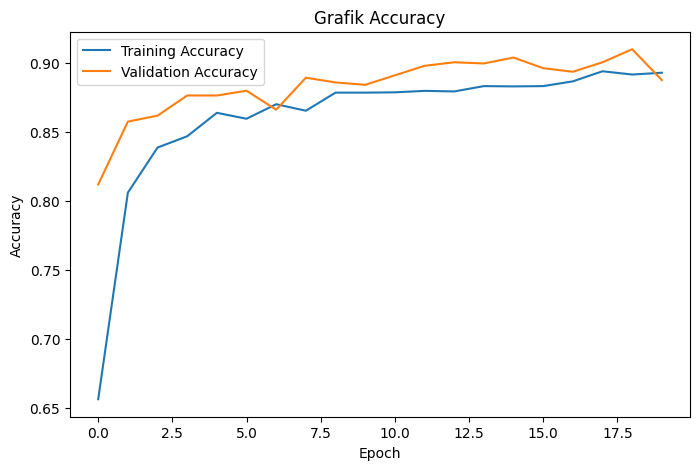

In [22]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Grafik Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

##Visualisasi Loss

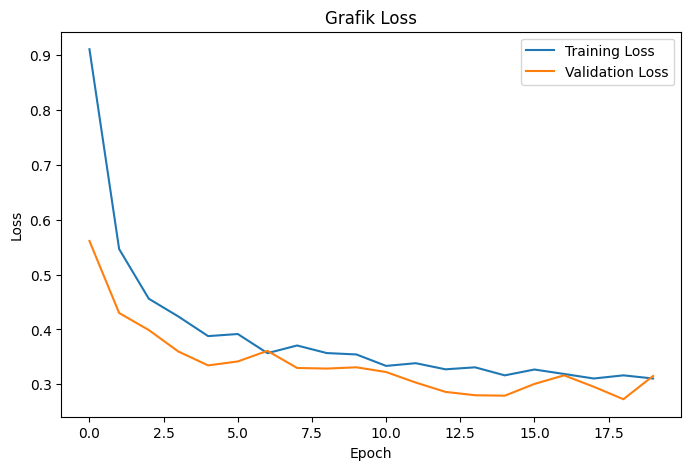

In [23]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Grafik Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

##Prediksi Data Uji

In [24]:
predictions = model.predict(test_generator)
predicted_class = np.argmax(predictions, axis=1)
true_class = test_generator.classes

46/46 ━━━━━━━━━━━━━━━━━━━━ 11s 155ms/step


##Menampilkan Nama Kelas

In [25]:
class_names = list(test_generator.class_indices.keys())
print(class_names)

['Tomato__early_blight', 'Tomato__healthy', 'Tomato__late_blight', 'Tomato__leaf_mold', 'Tomato__septoria_leaf_spot']


## Classification Report

In [26]:
print(classification_report(
    true_class,
    predicted_class,
    target_names=class_names
))

                            precision    recall  f1-score   support

      Tomato__early_blight       0.86      0.74      0.80       202
           Tomato__healthy       0.97      0.99      0.98       320
       Tomato__late_blight       0.91      0.95      0.93       384
         Tomato__leaf_mold       0.90      0.94      0.92       191
Tomato__septoria_leaf_spot       0.92      0.92      0.92       356

                  accuracy                           0.92      1453
                 macro avg       0.91      0.91      0.91      1453
              weighted avg       0.92      0.92      0.92      1453



##Confusion Matrix

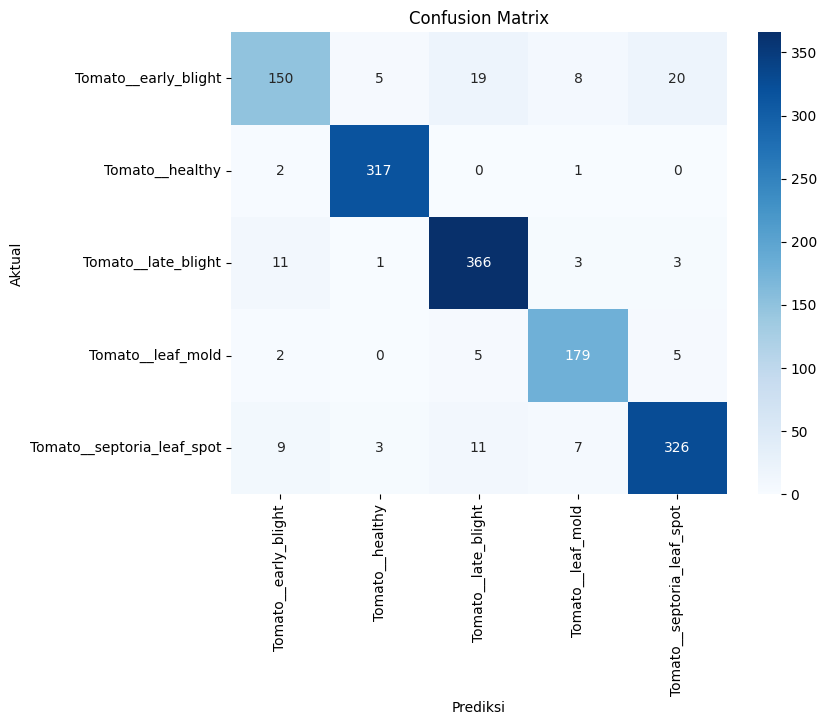

In [27]:
cm = confusion_matrix(true_class, predicted_class)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix")

plt.show()

##Simpan Model

In [28]:
model.save("/content/cnn_tomato_model.keras")
print("Model berhasil disimpan!")

Model berhasil disimpan!
